In [47]:
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [49]:
ibm = yf.download(tickers = 'IBM', period = '5y', interval = '1d', rounding = True)
walmart = yf.download(tickers = 'WMT', period = '5y', interval = '1d', rounding = True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [51]:
ibm

Price,Close,High,Low,Open,Volume
Ticker,IBM,IBM,IBM,IBM,IBM
Date,,,,,
2021-04-05,106.46,107.06,104.48,104.67,5722980
2021-04-06,105.12,106.23,105.02,106.19,3787566
2021-04-07,105.68,105.68,104.78,104.82,3112896
2021-04-08,105.83,106.23,105.07,105.39,4275211
2021-04-09,106.30,106.31,105.50,105.63,3162999
...,...,...,...,...,...
2026-03-27,236.34,239.44,233.75,238.85,4853700
2026-03-30,237.25,240.21,236.13,237.80,3882600


In [53]:
walmart

Price,Close,High,Low,Open,Volume
Ticker,WMT,WMT,WMT,WMT,WMT
Date,,,,,
2021-04-05,43.52,43.74,42.51,42.67,40043100
2021-04-06,43.72,43.99,43.23,43.42,31044600
2021-04-07,43.63,43.93,43.58,43.79,20361600
2021-04-08,43.60,44.04,43.59,43.83,19095600
2021-04-09,43.62,43.72,43.29,43.58,20676600
...,...,...,...,...,...
2026-03-27,122.89,124.27,121.82,122.03,16543300
2026-03-30,123.50,125.26,123.14,123.71,20428900


In [55]:
# Extraemos solo la columna de cierre para IBM
ibm = ibm['Close']['IBM']
walmart = walmart['Close']['WMT']
print(ibm)
print("__________________________________")
print(walmart)

Date
2021-04-05    106.46
2021-04-06    105.12
2021-04-07    105.68
2021-04-08    105.83
2021-04-09    106.30
               ...  
2026-03-27    236.34
2026-03-30    237.25
2026-03-31    242.39
2026-04-01    243.14
2026-04-02    248.16
Name: IBM, Length: 1256, dtype: float64
__________________________________
Date
2021-04-05     43.52
2021-04-06     43.72
2021-04-07     43.63
2021-04-08     43.60
2021-04-09     43.62
               ...  
2026-03-27    122.89
2026-03-30    123.50
2026-03-31    124.28
2026-04-01    124.74
2026-04-02    125.79
Name: WMT, Length: 1256, dtype: float64


In [63]:
# Combinamos ambas series en un solo DataFrame
df = pd.DataFrame({'IBM': ibm,'Walmart': walmart})

# Opcional: Eliminar filas donde falten datos (por si hubo días festivos distintos)
df = df.dropna()

# Visualizar el resultado
print(df.head())

               IBM  Walmart
Date                       
2021-04-05  106.46    43.52
2021-04-06  105.12    43.72
2021-04-07  105.68    43.63
2021-04-08  105.83    43.60
2021-04-09  106.30    43.62


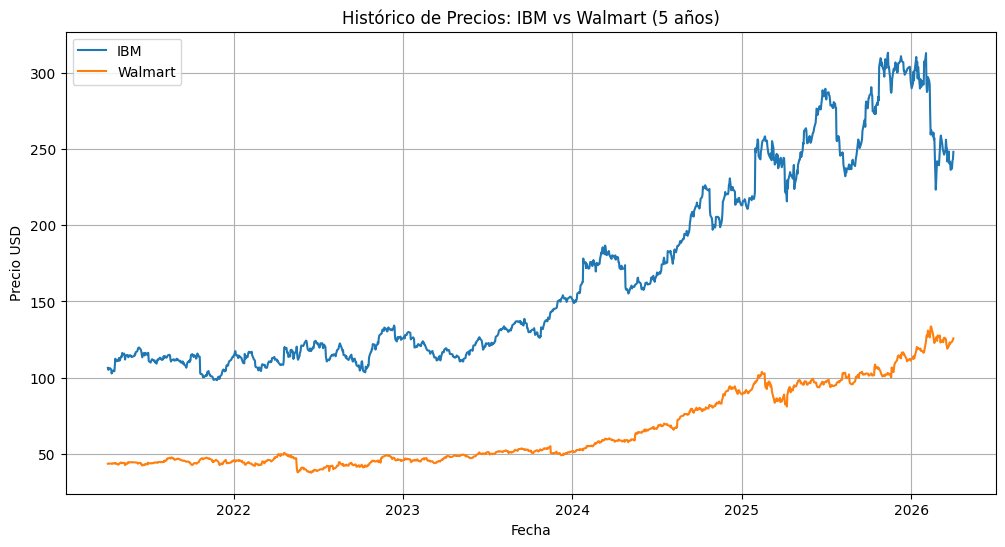

In [57]:
import matplotlib.pyplot as plt

# Graficar ambas series
plt.figure(figsize=(12,6))
plt.plot(ibm, label='IBM')
plt.plot(walmart, label='Walmart')

plt.title('Histórico de Precios: IBM vs Walmart (5 años)')
plt.xlabel('Fecha')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(True)
plt.show()

In [65]:
# Calculamos la matriz de correlación
correlacion = df.corr()
print(correlacion)

# Para obtener el valor específico
r = df['IBM'].corr(df['Walmart'])
print(f"\nEl índice de correlación de Pearson es: {r:.4f}")

             IBM  Walmart
IBM      1.00000  0.95547
Walmart  0.95547  1.00000

El índice de correlación de Pearson es: 0.9555


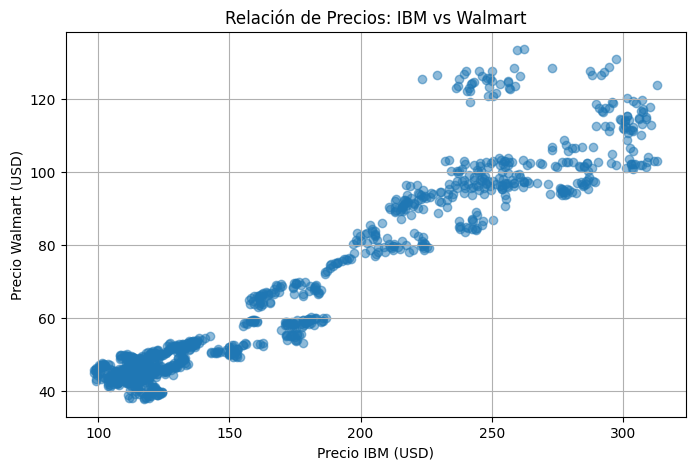

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['IBM'], df['Walmart'], alpha=0.5)
plt.title('Relación de Precios: IBM vs Walmart')
plt.xlabel('Precio IBM (USD)')
plt.ylabel('Precio Walmart (USD)')
plt.grid(True)
plt.show()

In [39]:
# Extraemos solo la columna de cierre
ibm_walmart = ibm_walmart['Close']
ibm_walmart

Ticker,IBM,WMT
Date,,
2021-05-01,112.58,44.33
2021-06-01,116.09,44.18
2021-07-01,111.63,44.66
2021-08-01,111.14,46.40
2021-09-01,111.29,43.83
2021-10-01,100.21,46.99
2021-11-01,98.12,44.22
2021-12-01,113.49,45.50
2022-01-01,113.41,44.14


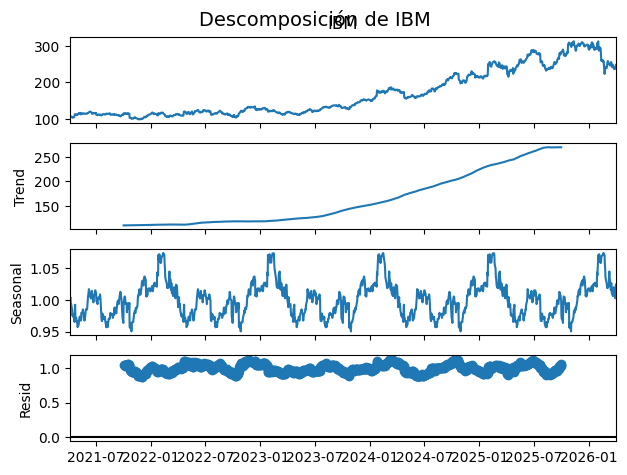

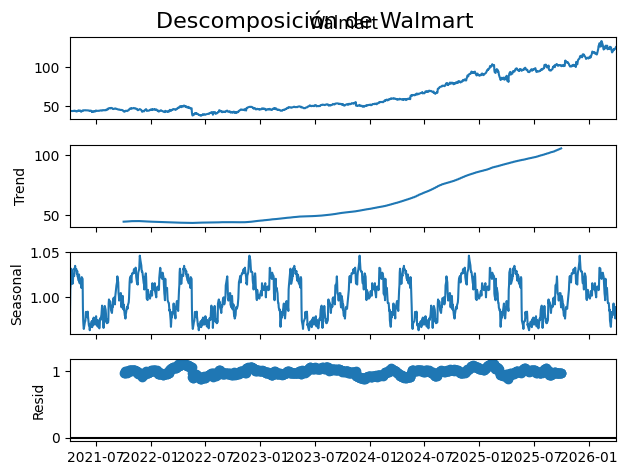

In [77]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Descomposición Estacional
# Para IBM
res_ibm = seasonal_decompose(df['IBM'], model='multiplicative', period=252)
res_ibm.plot()
plt.suptitle('Descomposición de IBM', fontsize=14)

# Para Walmart
res_wmt = seasonal_decompose(df['Walmart'], model='multiplicative', period=252)
res_wmt.plot()
plt.suptitle('Descomposición de Walmart', fontsize=14)

plt.show()


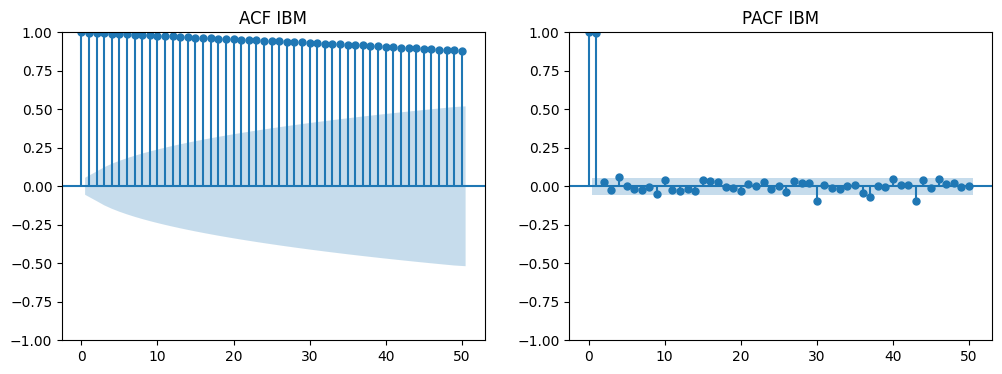

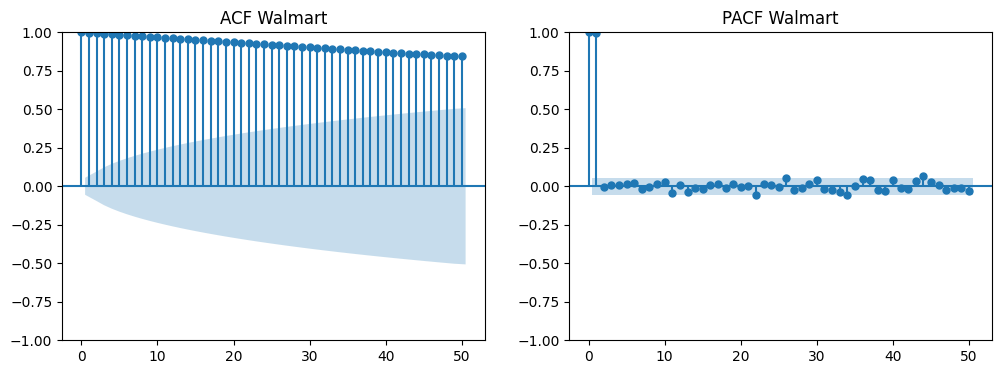

In [79]:
# 2. Correlogramas (ACF y PACF)
# IBM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['IBM'], lags=50, ax=ax1, title='ACF IBM')
plot_pacf(df['IBM'], lags=50, ax=ax2, title='PACF IBM')

# Walmart
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['Walmart'], lags=50, ax=ax3, title='ACF Walmart')
plot_pacf(df['Walmart'], lags=50, ax=ax4, title='PACF Walmart')

plt.show()

In [73]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(series, name):
    print(f'--- Prueba de Dickey-Fuller para {name} ---')
    result = adfuller(series.dropna())
    print(f'Estadístico ADF: {result[0]:.4f}')
    print(f'p-valor: {result[1]:.4f}')
    print('Valores Críticos:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    
    if result[1] <= 0.05:
        print("Resultado: La serie es ESTACIONARIA (Rechazamos H0)")
    else:
        print("Resultado: La serie NO ES ESTACIONARIA (No rechazamos H0)")
    print('\n')

# Aplicamos a las variables
test_stationarity(ibm, 'IBM')
test_stationarity(walmart, 'Walmart')

--- Prueba de Dickey-Fuller para IBM ---
Estadístico ADF: -0.6678
p-valor: 0.8549
Valores Críticos:
   1%: -3.4356
   5%: -2.8639
   10%: -2.5680
Resultado: La serie NO ES ESTACIONARIA (No rechazamos H0)


--- Prueba de Dickey-Fuller para Walmart ---
Estadístico ADF: 1.2914
p-valor: 0.9966
Valores Críticos:
   1%: -3.4356
   5%: -2.8639
   10%: -2.5680
Resultado: La serie NO ES ESTACIONARIA (No rechazamos H0)




Pronóstico (MA20) para el siguiente día - IBM: $246.68
Pronóstico (MA20) para el siguiente día - Walmart: $123.42


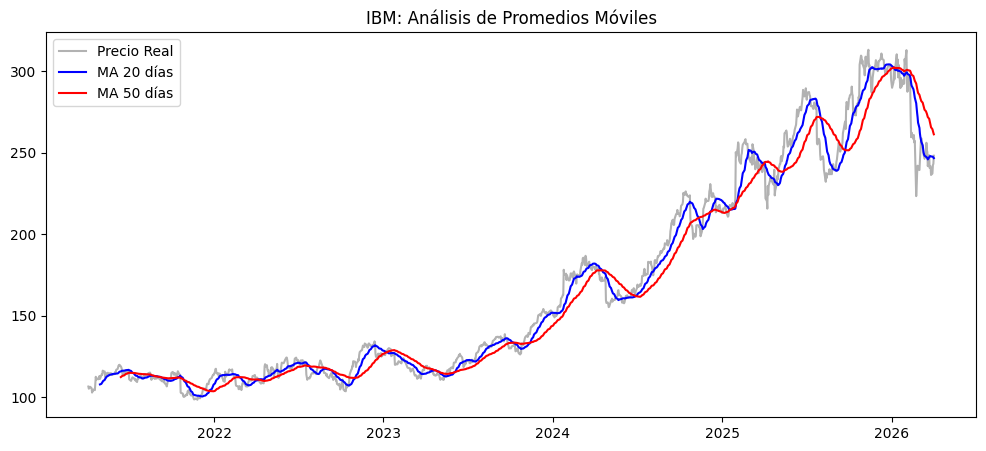

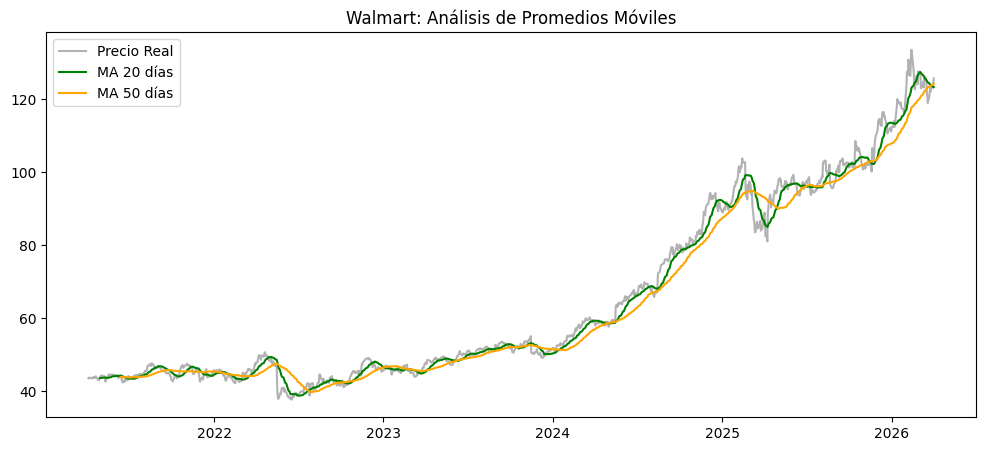

In [75]:
import matplotlib.pyplot as plt

# Calcular Promedios Móviles de 20 y 50 días
df['IBM_MA20'] = df['IBM'].rolling(window=20).mean()
df['IBM_MA50'] = df['IBM'].rolling(window=50).mean()

df['WMT_MA20'] = df['Walmart'].rolling(window=20).mean()
df['WMT_MA50'] = df['Walmart'].rolling(window=50).mean()

# Pronóstico Simple para el día siguiente
pronostico_ibm = df['IBM'].rolling(window=20).mean().iloc[-1]
pronostico_wmt = df['Walmart'].rolling(window=20).mean().iloc[-1]

print(f"Pronóstico (MA20) para el siguiente día - IBM: ${pronostico_ibm:.2f}")
print(f"Pronóstico (MA20) para el siguiente día - Walmart: ${pronostico_wmt:.2f}")

# Graficar IBM
plt.figure(figsize=(12,5))
plt.plot(df['IBM'], label='Precio Real', color='black', alpha=0.3)
plt.plot(df['IBM_MA20'], label='MA 20 días', color='blue')
plt.plot(df['IBM_MA50'], label='MA 50 días', color='red')
plt.title('IBM: Análisis de Promedios Móviles')
plt.legend()
plt.show()

# Graficar Walmart
plt.figure(figsize=(12,5))
plt.plot(df['Walmart'], label='Precio Real', color='black', alpha=0.3)
plt.plot(df['WMT_MA20'], label='MA 20 días', color='green')
plt.plot(df['WMT_MA50'], label='MA 50 días', color='orange')
plt.title('Walmart: Análisis de Promedios Móviles')
plt.legend()
plt.show()